In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Activation
from tensorflow.keras.optimizers import RMSprop, Adam
from matplotlib import pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model

In [2]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train=to_categorical(y_train, num_classes=10)
y_test=to_categorical(y_test, num_classes=10)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


In [ ]:
from tensorflow.keras.saving import register_keras_serializable
@register_keras_serializable()
class rgb_gris(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(rgb_gris, self).__init__(**kwargs)

    def call(self, inputs):
        # Asumimos formato de imágenes:
        channels = inputs.shape[-1]
        
        if channels == 3:  # RGB
            gray = 0.2989 * inputs[..., 0] + 0.5870 * inputs[..., 1] + 0.1140 * inputs[..., 2]
        elif channels == 4:  # RGBA
            gray = 0.2990 * inputs[..., 0] + 0.5870 * inputs[..., 1] + 0.1140 * inputs[..., 2]
        else:
            raise ValueError(f"Entrada inválida: se esperan 3 o 4 canales, pero se recibió {channels}")
        
        return tf.expand_dims(gray, axis=-1)
    def get_config(self):
        return super(rgb_gris, self).get_config()

In [42]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(rgb_gris(input_shape=(32, 32, 3)))  

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(16, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\Oscar\AppData\Local\Temp\ipykernel_19884\3891931980.py:5: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(rgb_gris, self).__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_gris (rgb_gris)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 50)             │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,088 (144.88 KB)

 Trainable params: 37,088 (144.88 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.fit(
        x_train,
        y_train,
        batch_size=100,
        epochs=20,
        verbose=1,
        validation_data=(x_test, y_test),
    )
model.save('modelo_rgb_gris.keras')  


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.2195 - loss: 2.1674 - val_accuracy: 0.3049 - val_loss: 1.9747
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3297 - loss: 1.8785 - val_accuracy: 0.3553 - val_loss: 1.7990
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3786 - loss: 1.7417 - val_accuracy: 0.3884 - val_loss: 1.7010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.4060 - loss: 1.6724 - val_accuracy: 0.4059 - val_loss: 1.6548
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.4219 - loss: 1.6293 - val_accuracy: 0.4199 - val_loss: 1.6201
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.4356 - loss: 1.5967 - val_accuracy: 0.4304 - val_loss: 1.5884
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.4431 - loss: 1.5732 - val_accuracy: 0.4363 - val_loss: 1.5764
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.4523 - loss: 1.5471 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Etiqueta predicha: rana
Etiqueta real: rana


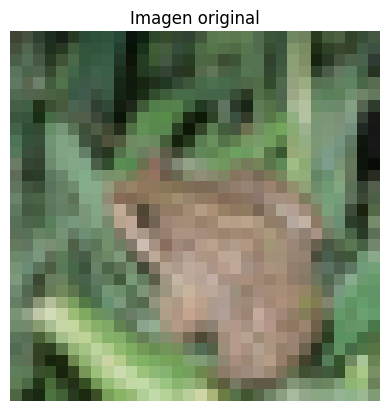

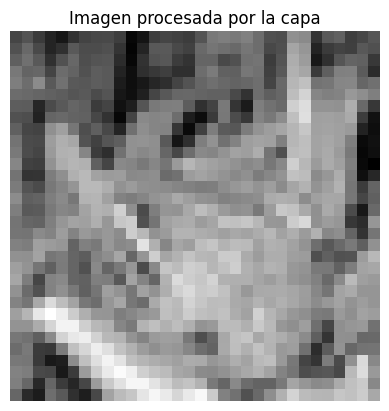

In [10]:
model = load_model('modelo_rgb_gris.keras', custom_objects={'rgb_gris': rgb_gris})
#El valor de la i determina el ejemplo con el que se probará al modelo 
i=4
x_prueba=x_test[i]
pred = np.expand_dims(x_prueba, axis=0) 
predictions = model.predict(pred)
clase_predicha = np.argmax(predictions)
clase_real = np.argmax(y_test[i])
capa_rgb_gris = rgb_gris()
x_bn = capa_rgb_gris(x_prueba)

labels = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']
print(f'Etiqueta predicha: {labels[clase_predicha]}')
print(f'Etiqueta real: {labels[clase_real]}')

plt.imshow(x_prueba)

plt.title("Imagen original")
plt.axis('off')
plt.show()

plt.imshow(tf.squeeze(x_bn), cmap='gray')
plt.title("Imagen procesada por la capa")
plt.axis('off')
plt.show()